<style>
/* Paper-style layout for both Jupyter and nbconvert HTML. */
.jp-Notebook,
.jp-NotebookPanel-notebook,
main {
    max-width: 1080px;
    margin-left: auto !important;
    margin-right: auto !important;
}

.jp-RenderedHTMLCommon p,
.text_cell_render p {
    text-align: justify;
    text-justify: inter-word;
    line-height: 1.65;
}

.jp-OutputArea-output img,
.jp-RenderedImage img,
.output_png img,
div.output_area img,
div.output_subarea img {
    display: block;
    max-width: 94%;
    height: auto;
    margin: 0.4rem auto 0.6rem !important;
}

.figure-caption {
    margin: 0.65rem auto 0.25rem !important;
    text-align: center !important;
    font-size: 1rem;
    line-height: 1.45 !important;
}

.figure-interpretation {
    max-width: 94%;
    margin: 0.35rem auto 1.75rem !important;
    text-align: justify !important;
    text-justify: inter-word;
    line-height: 1.65 !important;
}

.interpretation-label {
    font-style: italic;
    font-weight: 600;
}
</style>

# Change of Measure, Girsanov, and Pricing Measures

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

SEED = 3015

plt.rcParams.update({
    "figure.figsize": (9, 4.8),
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

BLUE = "#4C78A8"
ORANGE = "#F58518"
GREEN = "#54A24B"
PURPLE = "#8E6C8A"
GREY = "#6B7280"
LIGHT_GREY = "#D1D5DB"
INK = "#1F2937"


def normalized_weights(raw_weights):
    raw_weights = np.asarray(raw_weights, dtype=float)
    if np.any(raw_weights < 0.0):
        raise ValueError("Radon--Nikodym weights must be non-negative.")
    total = raw_weights.sum()
    if not np.isfinite(total) or total <= 0.0:
        raise ValueError("Weights must have a positive finite sum.")
    return raw_weights / total


def effective_sample_size(raw_weights):
    weights = normalized_weights(raw_weights)
    return 1.0 / np.sum(weights**2)


def normal_density(x, mean=0.0, variance=1.0):
    return np.exp(-0.5 * (x - mean) ** 2 / variance) / np.sqrt(
        2.0 * np.pi * variance
    )

## 1. A new measure is a density

Fix a finite horizon $T$ and a filtered probability space $(\Omega,\mathcal F,(\mathcal F_t),P)$. If $Q$ is absolutely continuous with respect to $P$ on $\mathcal F_T$, its Radon--Nikodym density is

$$
\Lambda_T=\left.\frac{dQ}{dP}\right|_{\mathcal F_T},
\qquad \Lambda_T\geq 0,
\qquad E_P[\Lambda_T]=1.
$$

For every $Q$-integrable random variable $X$,

$$
E_Q[X]=E_P[\Lambda_T X].
$$

The density process $\Lambda_t=E_P[\Lambda_T\mid\mathcal F_t]$ is a positive $P$-martingale. Bayes' formula gives

$$
E_Q[X\mid\mathcal F_t]
=\frac{E_P[\Lambda_T X\mid\mathcal F_t]}{\Lambda_t}
$$

whenever the ratio is well defined. If $\Lambda_T>0$ almost surely, then $P$ and $Q$ are equivalent on $\mathcal F_T$.

The normal tilt is the simplest example. Let $X\sim N(0,1)$ under $P$ and define

$$
\Lambda=\exp\!\left(\theta X-\frac12\theta^2\right).
$$

Completing the square in $\Lambda$ times the standard normal density shows that $X\sim N(\theta,1)$ under $Q$.

E_P[Lambda] estimate: 0.997938
Weighted mean:        1.198642 (target 1.200000)
Weighted variance:    0.994808 (target 1.000000)
Effective sample size: 43,592 / 180,000


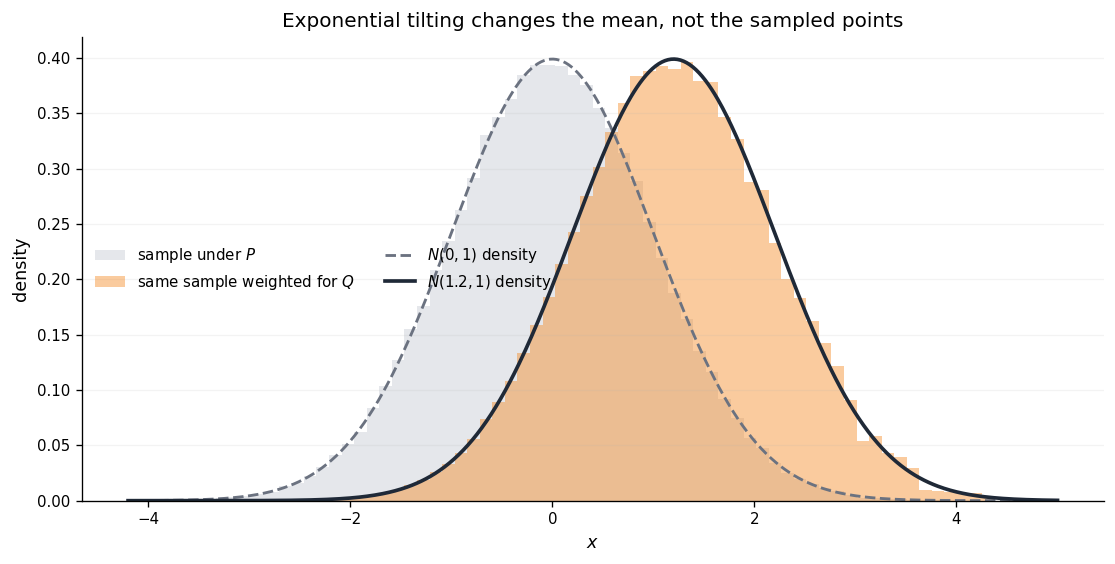

In [2]:
rng = np.random.default_rng(SEED + 1)
sample_size = 180_000
theta_tilt = 1.2

normal_sample = rng.standard_normal(sample_size)
likelihood_tilt = np.exp(
    theta_tilt * normal_sample - 0.5 * theta_tilt**2
)
weights_tilt = normalized_weights(likelihood_tilt)

weighted_mean = np.sum(weights_tilt * normal_sample)
weighted_variance = np.sum(
    weights_tilt * (normal_sample - weighted_mean) ** 2
)

print(f"E_P[Lambda] estimate: {likelihood_tilt.mean():.6f}")
print(f"Weighted mean:        {weighted_mean:.6f} (target {theta_tilt:.6f})")
print(f"Weighted variance:    {weighted_variance:.6f} (target 1.000000)")
print(
    "Effective sample size: "
    f"{effective_sample_size(likelihood_tilt):,.0f} / {sample_size:,}"
)

display_grid = np.linspace(-4.2, 5.0, 600)
bins = np.linspace(-4.2, 5.0, 75)

fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.hist(
    normal_sample,
    bins=bins,
    density=True,
    color=LIGHT_GREY,
    alpha=0.55,
    label=r"sample under $P$",
)
ax.hist(
    normal_sample,
    bins=bins,
    weights=weights_tilt,
    density=True,
    color=ORANGE,
    alpha=0.42,
    label=r"same sample weighted for $Q$",
)
ax.plot(
    display_grid,
    normal_density(display_grid),
    color=GREY,
    linestyle="--",
    linewidth=1.7,
    label=r"$N(0,1)$ density",
)
ax.plot(
    display_grid,
    normal_density(display_grid, mean=theta_tilt),
    color=INK,
    linewidth=2.2,
    label=rf"$N({theta_tilt:.1f},1)$ density",
)
ax.set_title("Exponential tilting changes the mean, not the sampled points")
ax.set_xlabel(r"$x$")
ax.set_ylabel("density")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 1.</strong> A standard normal sample under $P$ and the same observations reweighted by $\Lambda=\exp(1.2X-1.2^2/2)$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The unweighted histogram follows $N(0,1)$, while the weighted histogram follows $N(1.2,1)$. The computation changes expectations by changing the contribution of each observation; it does not alter the observations themselves. The reported effective sample size records the loss of Monte Carlo information caused by uneven weights.</p>

## 2. Girsanov's theorem removes Brownian drift

Let $B$ be a $P$-Brownian motion and let $H$ be predictable with $\int_0^T H_s^2\,ds<\infty$ almost surely. Define the stochastic exponential

$$
\Lambda_t
=\exp\!\left(
-\int_0^t H_s\,dB_s
-\frac12\int_0^t H_s^2\,ds
\right).
$$

This process is a positive local martingale. Girsanov's theorem requires the additional condition that $\Lambda$ is a true martingale with $E_P[\Lambda_T]=1$. A standard sufficient condition is Novikov's condition,

$$
E_P\!\left[
\exp\!\left(\frac12\int_0^T H_s^2\,ds\right)
\right]<\infty.
$$

Under the measure $Q$ defined by $dQ/dP=\Lambda_T$,

$$
W_t=B_t+\int_0^t H_s\,ds
$$

is a $Q$-Brownian motion. In the constant case $H_s=\theta$,

$$
\Lambda_T=\exp\!\left(-\theta B_T-\frac12\theta^2T\right),
\qquad W_t=B_t+\theta t.
$$

The sign convention is fixed by these two formulas. For an SDE $dX_t=b_P(t,X_t)\,dt+\sigma(t,X_t)\,dB_t$ with $\sigma\neq0$, choosing

$$
H_t=\frac{b_P(t,X_t)-b_Q(t,X_t)}{\sigma(t,X_t)}
$$

changes the drift from $b_P$ to $b_Q$ while leaving the diffusion coefficient unchanged.

E_P[Lambda_T] estimate: 0.992583
Maximum |weighted E_Q[W_t]|: 0.011806
Effective sample size: 22,568 / 60,000


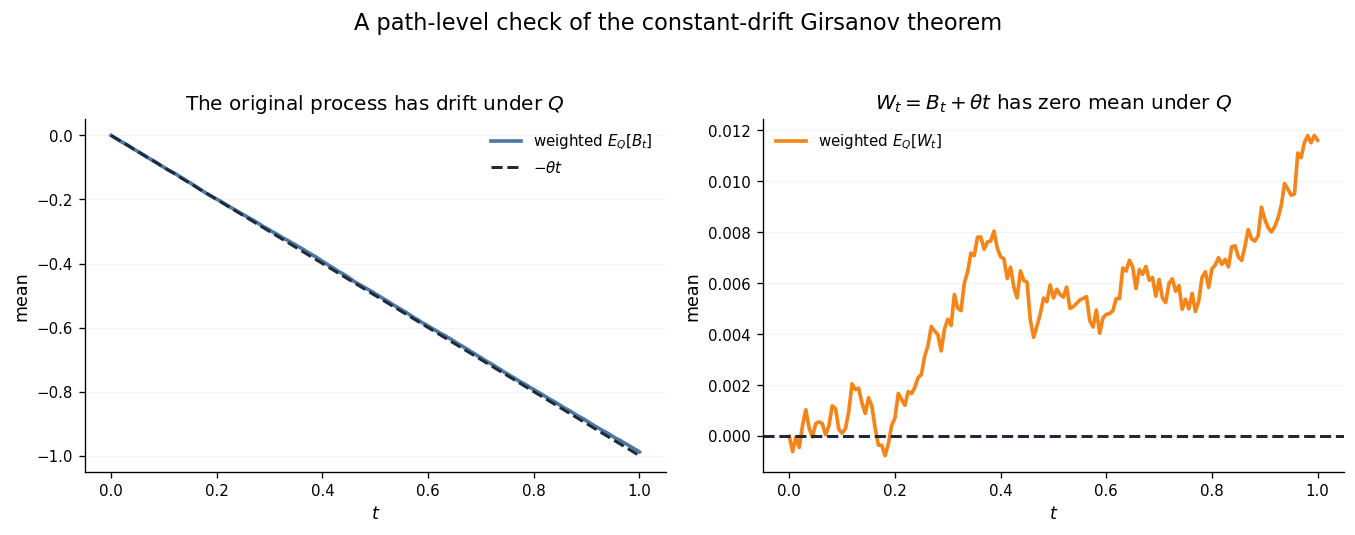

In [3]:
rng = np.random.default_rng(SEED + 2)
horizon = 1.0
theta_girsanov = 1.0
path_count = 60_000
time_steps = 160
dt = horizon / time_steps
time_grid = np.linspace(0.0, horizon, time_steps + 1)

brownian_increments = np.sqrt(dt) * rng.standard_normal(
    (path_count, time_steps)
)
brownian_paths = np.concatenate(
    (
        np.zeros((path_count, 1)),
        np.cumsum(brownian_increments, axis=1),
    ),
    axis=1,
)

terminal_brownian = brownian_paths[:, -1]
likelihood_girsanov = np.exp(
    -theta_girsanov * terminal_brownian
    - 0.5 * theta_girsanov**2 * horizon
)
weights_girsanov = normalized_weights(likelihood_girsanov)

mean_brownian_under_q = weights_girsanov @ brownian_paths
mean_shifted_under_q = mean_brownian_under_q + theta_girsanov * time_grid
maximum_shifted_mean = np.max(np.abs(mean_shifted_under_q))

print(f"E_P[Lambda_T] estimate: {likelihood_girsanov.mean():.6f}")
print(f"Maximum |weighted E_Q[W_t]|: {maximum_shifted_mean:.6f}")
print(
    "Effective sample size: "
    f"{effective_sample_size(likelihood_girsanov):,.0f} / {path_count:,}"
)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5))

axes[0].plot(
    time_grid,
    mean_brownian_under_q,
    color=BLUE,
    linewidth=2.2,
    label=r"weighted $E_Q[B_t]$",
)
axes[0].plot(
    time_grid,
    -theta_girsanov * time_grid,
    color=INK,
    linestyle="--",
    linewidth=1.8,
    label=r"$-\theta t$",
)
axes[0].set_title(r"The original process has drift under $Q$")
axes[0].set_xlabel(r"$t$")
axes[0].set_ylabel("mean")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.14)

axes[1].plot(
    time_grid,
    mean_shifted_under_q,
    color=ORANGE,
    linewidth=2.2,
    label=r"weighted $E_Q[W_t]$",
)
axes[1].axhline(0.0, color=INK, linestyle="--", linewidth=1.8)
axes[1].set_title(r"$W_t=B_t+\theta t$ has zero mean under $Q$")
axes[1].set_xlabel(r"$t$")
axes[1].set_ylabel("mean")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.14)

fig.suptitle("A path-level check of the constant-drift Girsanov theorem", fontsize=13.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

del brownian_increments, brownian_paths

<p class="figure-caption"><strong>Figure 2.</strong> Weighted path means for $B_t$ and $W_t=B_t+t$ when $dQ/dP=\exp(-B_T-T/2)$, using 60,000 Brownian paths on $[0,1]$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Under $Q$, the weighted mean of $B_t$ follows $-t$. Adding the compensating finite-variation term produces $W_t=B_t+t$, whose weighted mean remains close to zero. This checks the drift conclusion of Girsanov's theorem; Brownian covariance is preserved because an equivalent measure change does not alter quadratic variation.</p>

## 3. The risk-neutral measure in the Black--Scholes model

Assume a frictionless market with filtration generated by $B$, a traded money-market account $\beta_t=e^{rt}$, and one stock satisfying

$$
\frac{dS_t}{S_t}=\mu\,dt+\sigma\,dB_t,
\qquad S_0>0,
\qquad \sigma>0.
$$

Set the market price of Brownian risk to

$$
\theta=\frac{\mu-r}{\sigma}
$$

and define $Q$ by

$$
\left.\frac{dQ}{dP}\right|_{\mathcal F_T}
=\exp\!\left(-\theta B_T-\frac12\theta^2T\right).
$$

Then $W_t=B_t+\theta t$ is a $Q$-Brownian motion and

$$
\frac{dS_t}{S_t}=r\,dt+\sigma\,dW_t.
$$

Consequently, $S_t/\beta_t$ is a $Q$-martingale. In this one-stock, one-Brownian model the equivalent martingale measure is unique, and attainable claims are valued by discounted $Q$-expectation. The measure $Q$ is called risk-neutral because traded assets earn the money-market rate under $Q$; it is a pricing measure, not an estimate of real-world returns.

S_0:                              100.000000


E_P[Lambda_T exp(-rT) S_T]:      99.996934
Monte Carlo standard error:      0.032180
Relative pricing error:          -0.003%
E_P[Lambda_T] estimate:          1.000076
Effective sample size:           211,370 / 220,000


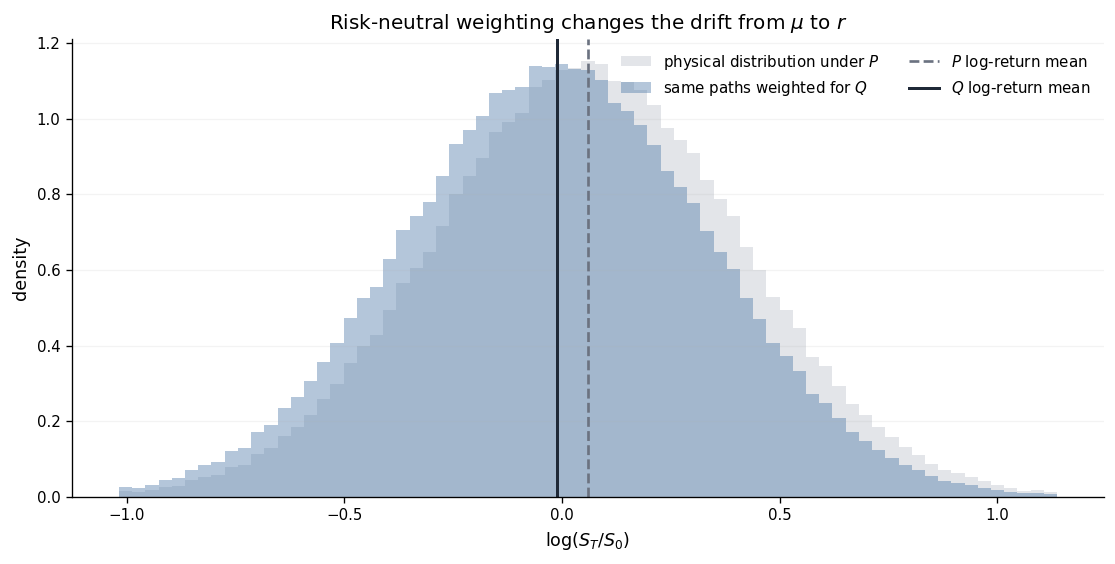

In [4]:
rng = np.random.default_rng(SEED + 3)
stock_initial = 100.0
physical_drift = 0.12
rate = 0.05
volatility = 0.35
maturity = 1.0
terminal_count = 220_000

market_price_of_risk = (physical_drift - rate) / volatility
terminal_brownian = np.sqrt(maturity) * rng.standard_normal(terminal_count)
terminal_stock_under_p = stock_initial * np.exp(
    (physical_drift - 0.5 * volatility**2) * maturity
    + volatility * terminal_brownian
)
likelihood_risk_neutral = np.exp(
    -market_price_of_risk * terminal_brownian
    - 0.5 * market_price_of_risk**2 * maturity
)
weights_risk_neutral = normalized_weights(likelihood_risk_neutral)

discounted_weighted_stock = (
    likelihood_risk_neutral
    * np.exp(-rate * maturity)
    * terminal_stock_under_p
)
stock_estimate = discounted_weighted_stock.mean()
stock_standard_error = discounted_weighted_stock.std(ddof=1) / np.sqrt(
    terminal_count
)

print(f"S_0:                              {stock_initial:.6f}")
print(f"E_P[Lambda_T exp(-rT) S_T]:      {stock_estimate:.6f}")
print(f"Monte Carlo standard error:      {stock_standard_error:.6f}")
print(f"Relative pricing error:          {(stock_estimate / stock_initial - 1):.3%}")
print(f"E_P[Lambda_T] estimate:          {likelihood_risk_neutral.mean():.6f}")
print(
    "Effective sample size:           "
    f"{effective_sample_size(likelihood_risk_neutral):,.0f} / {terminal_count:,}"
)

log_return = np.log(terminal_stock_under_p / stock_initial)
bins = np.linspace(np.percentile(log_return, 0.1), np.percentile(log_return, 99.9), 72)

fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.hist(
    log_return,
    bins=bins,
    density=True,
    color=LIGHT_GREY,
    alpha=0.6,
    label=r"physical distribution under $P$",
)
ax.hist(
    log_return,
    bins=bins,
    weights=weights_risk_neutral,
    density=True,
    color=BLUE,
    alpha=0.42,
    label=r"same paths weighted for $Q$",
)
ax.axvline(
    (physical_drift - 0.5 * volatility**2) * maturity,
    color=GREY,
    linestyle="--",
    linewidth=1.6,
    label=r"$P$ log-return mean",
)
ax.axvline(
    (rate - 0.5 * volatility**2) * maturity,
    color=INK,
    linewidth=1.8,
    label=r"$Q$ log-return mean",
)
ax.set_title("Risk-neutral weighting changes the drift from $\mu$ to $r$")
ax.set_xlabel(r"$\log(S_T/S_0)$")
ax.set_ylabel("density")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.14)
plt.tight_layout()
plt.show()

<p class="figure-caption"><strong>Figure 3.</strong> Physical and risk-neutral terminal log-return distributions for $S_0=100$, $\mu=0.12$, $r=0.05$, $\sigma=0.35$, and $T=1$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> The likelihood ratio shifts the mean log return from $(\mu-\sigma^2/2)T$ to $(r-\sigma^2/2)T$ without changing volatility. The numerical pricing identity $E_P[\Lambda_Te^{-rT}S_T]=S_0$ is reported with its Monte Carlo standard error, so simulation noise can be separated from a mathematical or implementation error.</p>

## 4. Change of numeraire

Let $\beta$ and $N$ be strictly positive traded numeraires. Suppose that under $Q^\beta$ the ratio $N_t/\beta_t$ is a positive martingale. The measure associated with $N$ is defined by

$$
\left.\frac{dQ^N}{dQ^\beta}\right|_{\mathcal F_t}
=\frac{N_t/\beta_t}{N_0/\beta_0}.
$$

The direction of this density matters: the target numeraire $N$ appears in the numerator. If $X$ is an attainable payoff at time $T$, then

$$
V_t
=\beta_t E_{Q^\beta}\!\left[\frac{X}{\beta_T}\middle|\mathcal F_t\right]
=N_t E_{Q^N}\!\left[\frac{X}{N_T}\middle|\mathcal F_t\right].
$$

In particular, if $S_t/\beta_t$ is a $Q^\beta$-martingale, then $S_t/N_t$ is a $Q^N$-martingale. The next experiment takes $N=S^{(2)}$ and starts from the money-market measure $Q^\beta$.

E_Qbeta[dQ^S2/dQbeta]:        0.998389
E_QS2[S1_T/S2_T]:             1.249351
S1_0/S2_0:                    1.250000
Monte Carlo standard error:   0.000753
Relative error:               -0.052%
Effective sample size:       212,623 / 260,000


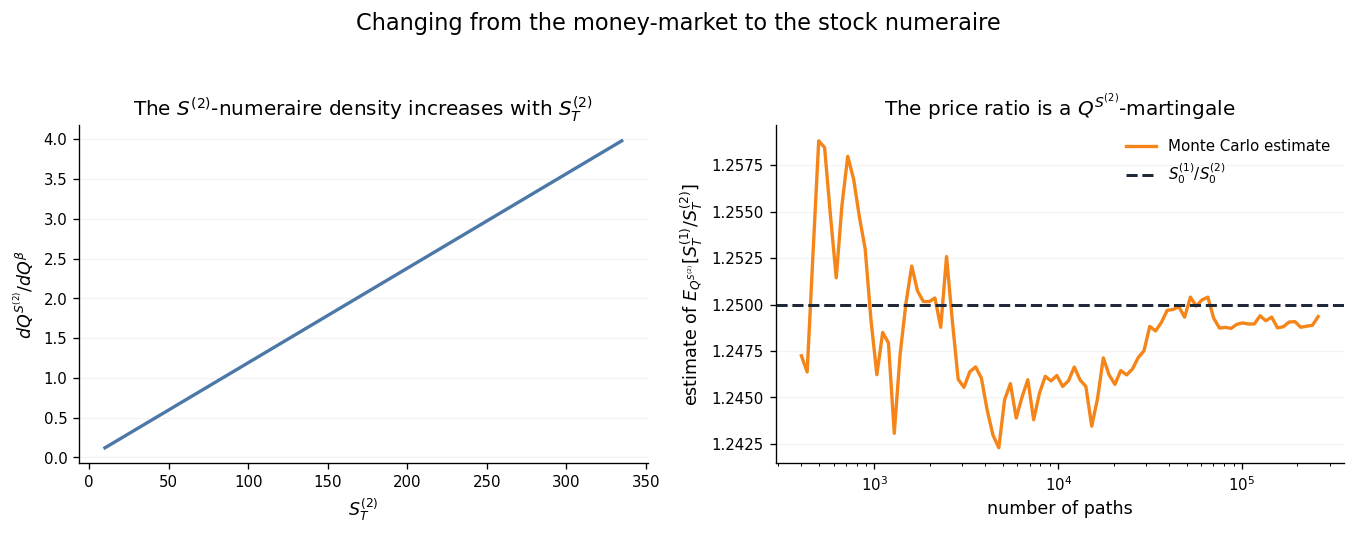

In [5]:
rng = np.random.default_rng(SEED + 4)
stock_one_initial = 100.0
stock_two_initial = 80.0
rate_numeraire = 0.05
maturity_numeraire = 1.0
volatility_one = 0.30
volatility_two = 0.45
correlation = 0.40
numeraire_paths = 260_000

normal_one = rng.standard_normal(numeraire_paths)
normal_two = (
    correlation * normal_one
    + np.sqrt(1.0 - correlation**2) * rng.standard_normal(numeraire_paths)
)

stock_one_terminal = stock_one_initial * np.exp(
    (rate_numeraire - 0.5 * volatility_one**2) * maturity_numeraire
    + volatility_one * np.sqrt(maturity_numeraire) * normal_one
)
stock_two_terminal = stock_two_initial * np.exp(
    (rate_numeraire - 0.5 * volatility_two**2) * maturity_numeraire
    + volatility_two * np.sqrt(maturity_numeraire) * normal_two
)
money_market_terminal = np.exp(rate_numeraire * maturity_numeraire)

# Correct density: dQ^{S2}/dQ^beta = (S2_T/beta_T)/(S2_0/beta_0), beta_0=1.
likelihood_numeraire = stock_two_terminal / (
    stock_two_initial * money_market_terminal
)
ratio_terminal = stock_one_terminal / stock_two_terminal
weighted_ratio_observations = likelihood_numeraire * ratio_terminal
ratio_estimate = weighted_ratio_observations.mean()
ratio_target = stock_one_initial / stock_two_initial
ratio_standard_error = weighted_ratio_observations.std(ddof=1) / np.sqrt(
    numeraire_paths
)

print(f"E_Qbeta[dQ^S2/dQbeta]:        {likelihood_numeraire.mean():.6f}")
print(f"E_QS2[S1_T/S2_T]:             {ratio_estimate:.6f}")
print(f"S1_0/S2_0:                    {ratio_target:.6f}")
print(f"Monte Carlo standard error:   {ratio_standard_error:.6f}")
print(f"Relative error:               {(ratio_estimate / ratio_target - 1):.3%}")
print(
    "Effective sample size:       "
    f"{effective_sample_size(likelihood_numeraire):,.0f} / {numeraire_paths:,}"
)

ordered = np.argsort(stock_two_terminal)
subsample = ordered[:: max(1, numeraire_paths // 2_000)]
running_sizes = np.unique(
    np.geomspace(400, numeraire_paths, 90).astype(int)
)
running_estimates = np.array([
    weighted_ratio_observations[:size].mean() for size in running_sizes
])

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5))

axes[0].plot(
    stock_two_terminal[subsample],
    likelihood_numeraire[subsample],
    color=BLUE,
    linewidth=2.0,
)
axes[0].set_title(r"The $S^{(2)}$-numeraire density increases with $S_T^{(2)}$")
axes[0].set_xlabel(r"$S_T^{(2)}$")
axes[0].set_ylabel(r"$dQ^{S^{(2)}}/dQ^\beta$")
axes[0].grid(axis="y", alpha=0.14)

axes[1].plot(
    running_sizes,
    running_estimates,
    color=ORANGE,
    linewidth=2.0,
    label="Monte Carlo estimate",
)
axes[1].axhline(
    ratio_target,
    color=INK,
    linestyle="--",
    linewidth=1.8,
    label=r"$S_0^{(1)}/S_0^{(2)}$",
)
axes[1].set_xscale("log")
axes[1].set_title(r"The price ratio is a $Q^{S^{(2)}}$-martingale")
axes[1].set_xlabel("number of paths")
axes[1].set_ylabel(r"estimate of $E_{Q^{S^{(2)}}}[S_T^{(1)}/S_T^{(2)}]$")
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.14)

fig.suptitle("Changing from the money-market to the stock numeraire", fontsize=13.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

<p class="figure-caption"><strong>Figure 4.</strong> The density for changing from the money-market measure $Q^\beta$ to the $S^{(2)}$-numeraire measure and the resulting estimate of $E_{Q^{S^{(2)}}}[S_T^{(1)}/S_T^{(2)}]$.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> Paths with a larger terminal numeraire receive more weight because $dQ^{S^{(2)}}/dQ^\beta=(S_T^{(2)}/\beta_T)/(S_0^{(2)}/\beta_0)$. With this orientation, the weighted expectation of $S_T^{(1)}/S_T^{(2)}$ converges to its initial ratio $1.25$. Using the reciprocal density would define the opposite measure change and fails this martingale check.</p>

## 5. Point-process likelihoods and weight stability

Let $N$ be a Poisson process with rate $\mu>0$ under $P_\mu$. On $\mathcal F_T$, the constant-rate likelihood for a target rate $\lambda>0$ is

$$
\frac{dP_\lambda}{dP_\mu}
=\exp\!\left((\mu-\lambda)T
+N_T(\log\lambda-\log\mu)\right).
$$

Thus a change of measure changes the compensator of a point process, just as Brownian Girsanov changes a drift. More generally, if $N$ has unit rate under $P$ and $\lambda_t>0$ is predictable, the candidate density is

$$
\Lambda_T
=\exp\!\left(
\int_0^T(1-\lambda_s)\,ds
+\int_0^T\log(\lambda_s)\,dN_s
\right).
$$

This formula defines the intended measure only when the associated stochastic exponential is a true martingale.

In computation, the identity $E_Q[X]=E_P[\Lambda_T X]$ is exact, but a finite sample can be unstable when a few weights dominate. For normalized weights $\bar w_i$, the diagnostic

$$
\operatorname{ESS}=\frac{1}{\sum_{i=1}^n \bar w_i^2}
$$

lies between $1$ and $n$. A small effective sample size signals high Monte Carlo variance; it does not invalidate the measure-change theorem.

E_Pmu[likelihood]:       1.003940
Weighted mean:           3.014812 (target 3.000000)
Weighted variance:       3.042646 (target 3.000000)
Effective sample size:  192,628 / 320,000


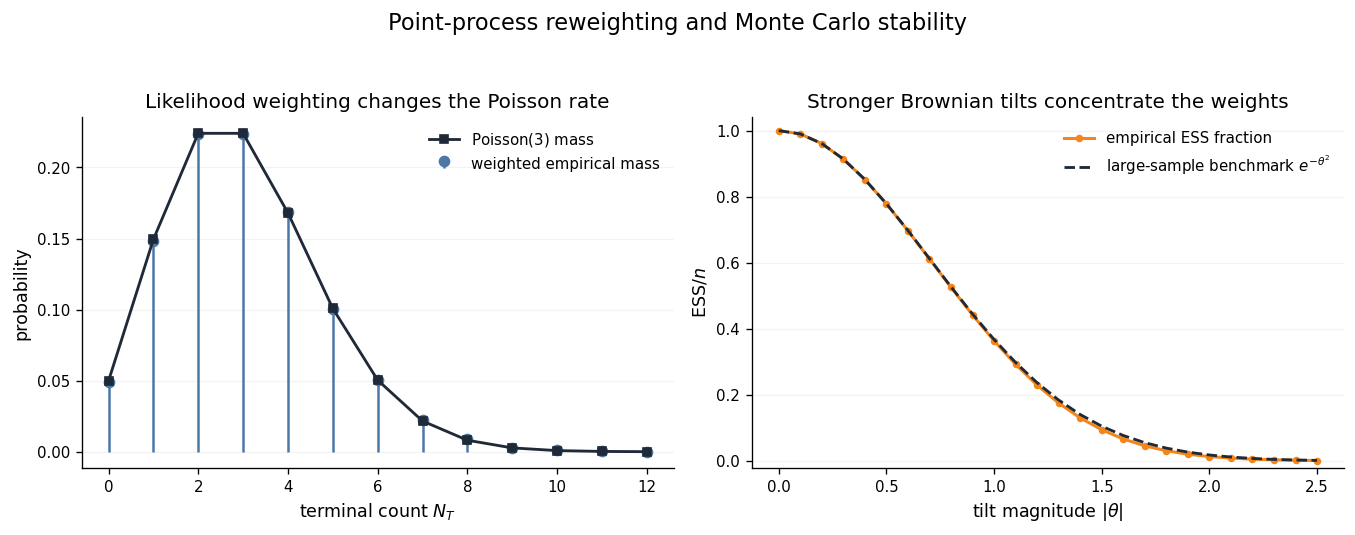

In [6]:
rng = np.random.default_rng(SEED + 5)
base_rate = 2.0
target_rate = 3.0
poisson_horizon = 1.0
poisson_count = 320_000

terminal_counts = rng.poisson(
    base_rate * poisson_horizon,
    size=poisson_count,
)
likelihood_poisson = np.exp(
    (base_rate - target_rate) * poisson_horizon
    + terminal_counts * (np.log(target_rate) - np.log(base_rate))
)
weights_poisson = normalized_weights(likelihood_poisson)

weighted_count_mean = np.sum(weights_poisson * terminal_counts)
weighted_count_variance = np.sum(
    weights_poisson * (terminal_counts - weighted_count_mean) ** 2
)

print(f"E_Pmu[likelihood]:       {likelihood_poisson.mean():.6f}")
print(
    f"Weighted mean:           {weighted_count_mean:.6f} "
    f"(target {target_rate * poisson_horizon:.6f})"
)
print(
    f"Weighted variance:       {weighted_count_variance:.6f} "
    f"(target {target_rate * poisson_horizon:.6f})"
)
print(
    "Effective sample size:  "
    f"{effective_sample_size(likelihood_poisson):,.0f} / {poisson_count:,}"
)

maximum_count = 12
count_grid = np.arange(maximum_count + 1)
weighted_mass = np.array([
    weights_poisson[terminal_counts == count].sum() for count in count_grid
])
target_mass = np.array([
    np.exp(-target_rate * poisson_horizon)
    * (target_rate * poisson_horizon) ** count
    / factorial(int(count))
    for count in count_grid
])

brownian_sample = rng.standard_normal(180_000)
tilt_grid = np.linspace(0.0, 2.5, 26)
empirical_ess_fraction = np.array([
    effective_sample_size(
        np.exp(-tilt * brownian_sample - 0.5 * tilt**2)
    )
    / brownian_sample.size
    for tilt in tilt_grid
])
theoretical_ess_fraction = np.exp(-tilt_grid**2)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.5))

axes[0].stem(
    count_grid,
    weighted_mass,
    basefmt=" ",
    linefmt=BLUE,
    markerfmt="o",
    label="weighted empirical mass",
)
axes[0].plot(
    count_grid,
    target_mass,
    color=INK,
    marker="s",
    markersize=4.5,
    linewidth=1.7,
    label=r"Poisson$(3)$ mass",
)
axes[0].set_title("Likelihood weighting changes the Poisson rate")
axes[0].set_xlabel(r"terminal count $N_T$")
axes[0].set_ylabel("probability")
axes[0].legend(frameon=False)
axes[0].grid(axis="y", alpha=0.14)

axes[1].plot(
    tilt_grid,
    empirical_ess_fraction,
    color=ORANGE,
    marker="o",
    markersize=3.5,
    linewidth=1.8,
    label="empirical ESS fraction",
)
axes[1].plot(
    tilt_grid,
    theoretical_ess_fraction,
    color=INK,
    linestyle="--",
    linewidth=1.7,
    label=r"large-sample benchmark $e^{-\theta^2}$",
)
axes[1].set_title("Stronger Brownian tilts concentrate the weights")
axes[1].set_xlabel(r"tilt magnitude $|\theta|$")
axes[1].set_ylabel(r"ESS$/n$")
axes[1].set_ylim(-0.02, 1.04)
axes[1].legend(frameon=False)
axes[1].grid(axis="y", alpha=0.14)

fig.suptitle("Point-process reweighting and Monte Carlo stability", fontsize=13.5)
plt.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

<p class="figure-caption"><strong>Figure 5.</strong> A Poisson rate change from $\mu=2$ to $\lambda=3$ and the effective-sample-size fraction for constant Brownian tilts.</p>

<p class="figure-interpretation"><span class="interpretation-label">Interpretation.</span> In the left panel, the weighted terminal-count distribution matches the target Poisson mass function. In the right panel, ESS decreases rapidly as the Brownian tilt grows; the empirical curve follows the large-sample benchmark $e^{-\theta^2}$. Measure-change identities remain valid, but reliable Monte Carlo estimation then requires more paths or a better sampling measure.</p>

## References

- Klebaner, F. C. *Introduction to Stochastic Calculus with Applications*, 3rd ed., Chapter 10, especially Theorems 10.10 and 10.15--10.18 for density processes and Brownian Girsanov, and Theorems 10.22--10.25 for point-process changes of measure.
- Klebaner, F. C. *Introduction to Stochastic Calculus with Applications*, 3rd ed., Chapter 11, especially Theorems 11.6--11.7 for equivalent martingale measures and pricing, and Theorems 11.17--11.18 for change of numeraire.